# LAB 7: ABC del aprendizaje de máquina 
## Víctor Palacios (1017271469)

# Problema

El dataset de viviendas de California corresponde a un conjunto de datos basado en el censo de 1990, que contiene información sobre los precios medios de las viviendas junto con diversas características demográficas y estructurales de los distritos en el estado de California.

A continuación, se describen las variables incluidas en el dataset:

- **longitude**: longitud del centroide del distrito (en grados). Indica la posición geográfica en el eje este-oeste.

- **latitude**: latitud del centroide del distrito (en grados). Indica la posición geográfica en el eje norte-sur.

- **housing_median_age**: edad media de las viviendas en el distrito (en años). Proporciona una aproximación al estado y antigüedad de las construcciones.

- **total_rooms**: número total de habitaciones en el distrito, sin distinción de tipo. Refleja la capacidad habitacional agregada.

- **total_bedrooms**: número total de dormitorios en el distrito. Representa los espacios destinados al descanso dentro de las viviendas.

- **population**: número total de habitantes del distrito. Permite inferir la densidad poblacional y la presión sobre la vivienda.

- **households**: número de hogares en el distrito. Un hogar corresponde a un grupo de personas que habitan una misma vivienda; esta variable describe la estructura residencial.

- **median_income**: ingreso medio por hogar (expresado en miles de dólares, $10^3$ USD). Indica el nivel socioeconómico de los residentes.

- **median_house_value**: valor medio de las viviendas (expresado en cientos de miles de dólares, $10^5$ USD). Esta es la **variable objetivo** del problema, ya que representa el precio promedio de las propiedades en cada distrito.

## TAREA

1. Leer el data frame en formato csv en la dirección 
https://raw.githubusercontent.com/hernansalinas/Curso_aprendizaje_estadistico/main/datasets/Sesion_07_housing.csv

In [1]:
import pandas as pd

# 1. Carga del conjunto de datos
url = "https://raw.githubusercontent.com/hernansalinas/Curso_aprendizaje_estadistico/main/datasets/Sesion_07_housing.csv"
df = pd.read_csv(url)

# 2. Inspección rápida de la estructura
print("Dimensiones del dataset:", df.shape)
print("\nPrimeras 5 filas:")
print(df.head())

# 3. Tipos de datos e información general
print("\nInformación de las columnas y tipos de datos:")
print(df.info())

Dimensiones del dataset: (20640, 10)

Primeras 5 filas:
   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -122.23     37.88                41.0        880.0           129.0   
1    -122.22     37.86                21.0       7099.0          1106.0   
2    -122.24     37.85                52.0       1467.0           190.0   
3    -122.25     37.85                52.0       1274.0           235.0   
4    -122.25     37.85                52.0       1627.0           280.0   

   population  households  median_income  median_house_value ocean_proximity  
0       322.0       126.0         8.3252            452600.0        NEAR BAY  
1      2401.0      1138.0         8.3014            358500.0        NEAR BAY  
2       496.0       177.0         7.2574            352100.0        NEAR BAY  
3       558.0       219.0         5.6431            341300.0        NEAR BAY  
4       565.0       259.0         3.8462            342200.0        NEAR BAY  

Información de las

2. Entender el estado de los datos, para ello puedo emplear los comandos básicos del pandas

df.info()

df.describe()

df.isnull().sum()

df.isna().sum()

In [2]:
# 1. Información general de tipos y conteos
print("--- Información General ---")
print(df.info())

# 2. Resumen estadístico (Detección de outliers y escalas)
print("\n--- Resumen Estadístico ---")
print(df.describe())

# 3. Detección de valores faltantes (Ambas funciones son equivalentes)
print("\n--- Valores Faltantes ---")
print(df.isnull().sum())

--- Información General ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB
None

--- Resumen Estadístico ---
          longitude      latitude  housing_median_age   total_rooms  \
count  20640.000000  20640.000000        20640.000000  20640.000000   
mean    -119.569704     35.631861           28.

In [6]:
print(df[['median_income', 'median_house_value', 'total_rooms' ]].describe())

       median_income  median_house_value   total_rooms
count   20640.000000        20640.000000  20640.000000
mean        3.870671       206855.816909   2635.763081
std         1.899822       115395.615874   2181.615252
min         0.499900        14999.000000      2.000000
25%         2.563400       119600.000000   1447.750000
50%         3.534800       179700.000000   2127.000000
75%         4.743250       264725.000000   3148.000000
max        15.000100       500001.000000  39320.000000


Estos dos últimos son equivalentes: 

3. ¿Cuántas variables tiene el dataset y de qué tipo son?

In [3]:
# Conteo de variables y tipos
print(f"El dataset tiene {df.shape[1]} variables (columnas).")
print("\nTipos de datos por columna:")
print(df.dtypes)

# Conteo de tipos de datos
print("\nResumen de tipos de datos:")
print(df.dtypes.value_counts())

El dataset tiene 10 variables (columnas).

Tipos de datos por columna:
longitude             float64
latitude              float64
housing_median_age    float64
total_rooms           float64
total_bedrooms        float64
population            float64
households            float64
median_income         float64
median_house_value    float64
ocean_proximity        object
dtype: object

Resumen de tipos de datos:
float64    9
object     1
Name: count, dtype: int64


4. ¿Existen valores faltantes? ¿En qué variables estan? ¿cuántos son?

In [7]:
# Calcular la suma de valores nulos por cada columna
valores_faltantes = df.isnull().sum()

# Filtrar solo aquellas columnas que tienen más de 0 valores faltantes
solo_faltantes = valores_faltantes[valores_faltantes > 0]

print("Variables con valores faltantes y su cantidad:")
print(solo_faltantes)

# Calcular el porcentaje para dimensionar el problema
porcentaje_faltantes = (solo_faltantes / len(df)) * 100
print("\nPorcentaje de valores faltantes respecto al total:")
print(porcentaje_faltantes)

Variables con valores faltantes y su cantidad:
total_bedrooms    207
dtype: int64

Porcentaje de valores faltantes respecto al total:
total_bedrooms    1.002907
dtype: float64


Basado en el análisis del dataset de California Housing:

**¿Existen valores faltantes?**
Sí, existen valores faltantes en el conjunto de datos.

**¿En qué variables están?**
Únicamente en la variable total_bedrooms (total de dormitorios).

**¿Cuántos son?**
Hay 207 registros con valores nulos (NaN).

5. Determinar los elementos únicos dentro de la columna **ocean_proximity**

In [8]:
# Obtener los valores únicos de la columna ocean_proximity
valores_unicos = df['ocean_proximity'].unique()

# Contar cuántas veces aparece cada valor (frecuencia)
conteo_categorias = df['ocean_proximity'].value_counts()

print("Elementos únicos en 'ocean_proximity':")
print(valores_unicos)

print("\nFrecuencia de cada categoría:")
print(conteo_categorias)

Elementos únicos en 'ocean_proximity':
['NEAR BAY' '<1H OCEAN' 'INLAND' 'NEAR OCEAN' 'ISLAND']

Frecuencia de cada categoría:
ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64


6. Para las columnas

cols = ["housing_median_age",   "total_rooms",  "total_bedrooms",   "population",   "households",   "median_income",    "median_house_value"]

Determinar el promedio de cada una de las columnas asociado a cada elementos unico de ocean_proximity, intenta con la operación groupby.

In [9]:
# Definir las columnas de interés
cols = ["housing_median_age", "total_rooms", "total_bedrooms", 
        "population", "households", "median_income", "median_house_value"]

# Agrupar por 'ocean_proximity' y calcular el promedio para las columnas seleccionadas
resumen_por_proximidad = df.groupby('ocean_proximity')[cols].mean()

# Mostrar el resultado
print("Promedio de variables según proximidad al océano:")
print(resumen_por_proximidad)

Promedio de variables según proximidad al océano:
                 housing_median_age  total_rooms  total_bedrooms   population  \
ocean_proximity                                                                 
<1H OCEAN                 29.279225  2628.343586      546.539185  1520.290499   
INLAND                    24.271867  2717.742787      533.881619  1391.046252   
ISLAND                    42.400000  1574.600000      420.400000   668.000000   
NEAR BAY                  37.730131  2493.589520      514.182819  1230.317467   
NEAR OCEAN                29.347254  2583.700903      538.615677  1354.008653   

                 households  median_income  median_house_value  
ocean_proximity                                                 
<1H OCEAN        517.744965       4.230682       240084.285464  
INLAND           477.447565       3.208996       124805.392001  
ISLAND           276.600000       2.744420       380440.000000  
NEAR BAY         488.616157       4.172885       259212.3

7. Construye un histograma para cada columna, puede emplear la libreria de seaborn.

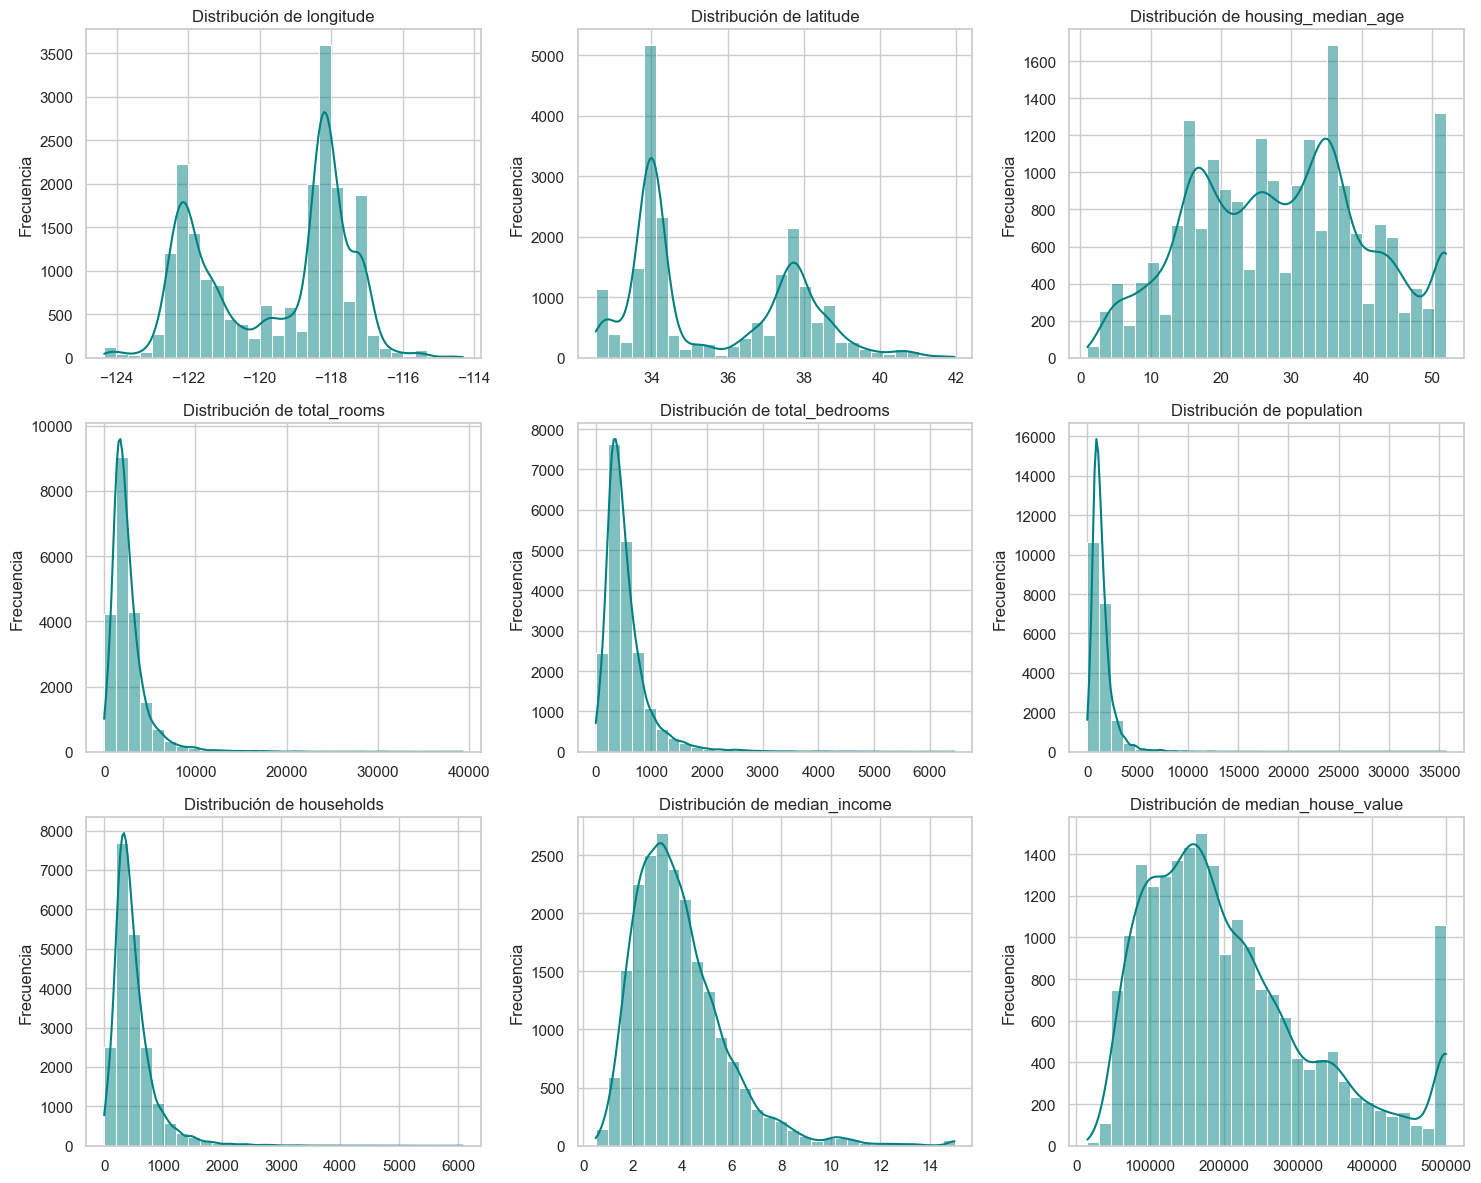

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de estilo
sns.set_theme(style="whitegrid")

# Seleccionar solo las columnas numéricas para los histogramas
cols_numericas = df.select_dtypes(include=['float64', 'int64']).columns

# Crear una figura con subplots
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(15, 12))
axes = axes.flatten()

for i, col in enumerate(cols_numericas):
    sns.histplot(df[col], bins=30, kde=True, ax=axes[i], color='teal')
    axes[i].set_title(f'Distribución de {col}', fontsize=12)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Frecuencia')

# Ajustar el diseño para que no se traslapen
plt.tight_layout()
plt.show()

8. Empleando el siguiente código realiza el gráfico boxplot,

**draw boxplot**

df.boxplot(column="median_house_value", by='ocean_proximity', sym = 'k.', figsize=(18,6))

**set title**

plt.title('Boxplot for comparing price per living space for each city')
plt.show()

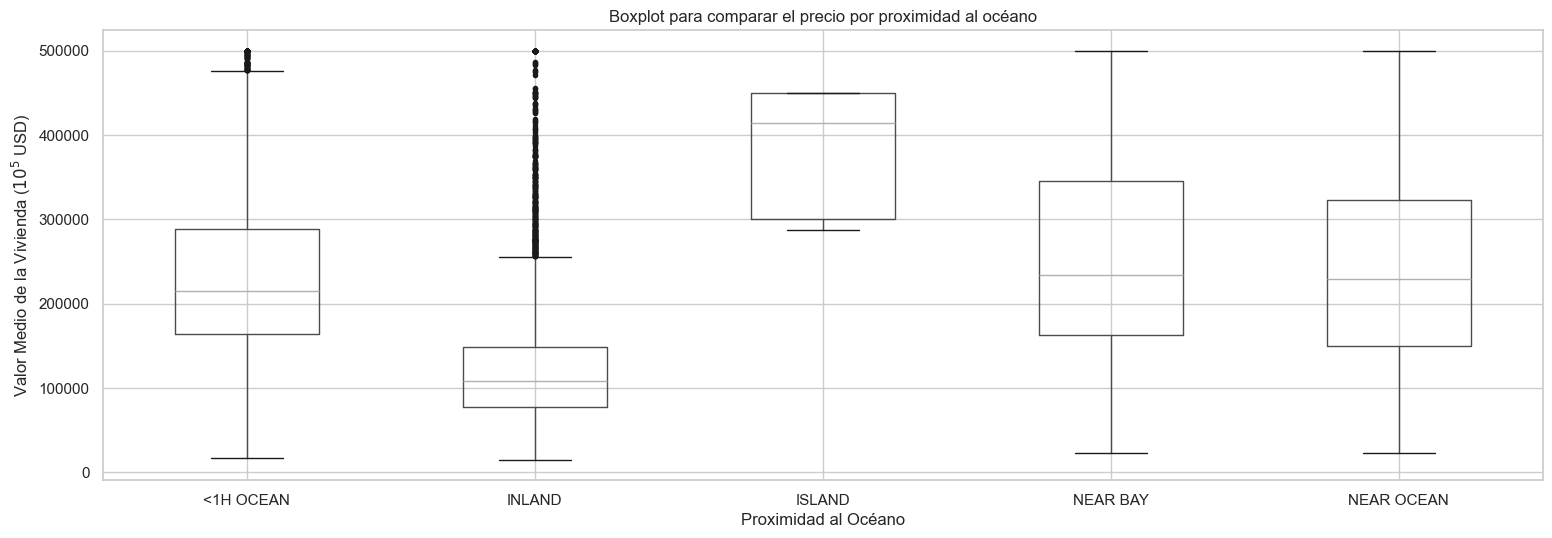

In [11]:
import matplotlib.pyplot as plt

# Configuración y visualización del Boxplot
df.boxplot(column="median_house_value", by='ocean_proximity', sym='k.', figsize=(18,6))

# Personalización de títulos
plt.title('Boxplot para comparar el precio por proximidad al océano')
plt.suptitle('') # Elimina el título automático de pandas para limpieza visual
plt.xlabel('Proximidad al Océano')
plt.ylabel('Valor Medio de la Vivienda ($10^5$ USD)')
plt.show()